## Dimention Reduction Method -Pathway 2
- In this model, we used the dimension reduction 
- It classifies the specialties into super classes, we researched 5 superclasses to be used
- used to Gridsearch to do hyperparameter tuning

### Linear SVC Model

#### Import all the libraries and packages needed

In [4]:
#import required libraries and packages
import pandas as pd
import numpy as np
import re
# Train-test split
from  sklearn.model_selection import train_test_split
#from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
#models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
#evaluation of the model
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
#visualization 
import matplotlib.pyplot as plt
# nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
#download stopwords from nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/obanda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Load and Prepreocess the data

In [5]:

# Load the cleaned dataset and clinical stop words
df = pd.read_csv("../data/super_clinical_mtsamples.csv")
# Load custom clinical stop words
with open("../data/clinical-stopwords.txt") as f:
    clinical_stopwords={
        line.strip().lower()
        for line in f
        if line.strip() and not line.startswith("#")
    }
#lematize and clean up the re
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    """
    Clean and preprocess clinical text for TF-IDF.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Remove numbers and punctuation (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Split text into individual words
    tokens = word_tokenize(text)

    # Remove stop words and lemmatize the remaining words
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in clinical_stopwords]

    # Join the cleaned words back into a sentence
    return " ".join(cleaned_tokens)
# Apply preprocessing to all transcriptions
df["cleaned_text"] = df["transcription"].apply(preprocess_text)


In [6]:

# define the features
X = df.cleaned_text
y = df.clinical_superclass

# split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Create TF-IDF instance
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2)
)

# Learn vocabulary and transform the training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

# Train the Linear SVC model
svc_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

# Evaluate using 5-fold cross validation
scores = cross_validate(
    svc_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1_macro"
)

#print("Fold scores:", scores)
print(f"SVC Mean Macro F1: {np.mean(scores['test_score']):.2f}")
#train the model
svc_model.fit(X_train_tfidf, y_train)

#time to make predictions
y_pred_svc = svc_model.predict(X_test_tfidf)

#model evaluation
accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred_svc))


SVC Mean Macro F1: 0.47
Accuracy: 0.60
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.19      0.25      0.22        87
internal_and_systemic_medicine       0.56      0.62      0.59       356
     neurology_and_behavioural       0.39      0.40      0.40        83
      rehab_and_applied_health       0.41      0.48      0.44        56
       surgical_and_procedural       0.76      0.67      0.71       622

                      accuracy                           0.60      1204
                     macro avg       0.46      0.48      0.47      1204
                  weighted avg       0.62      0.60      0.61      1204



#### Pipeline with Linear SVC model and Hyperparameter tuning

In [7]:
# # Define the features

# # Create a pipeline
# pipeline = Pipeline([
#     ("tfidf", TfidfVectorizer()),
#     ("svc", LinearSVC(class_weight="balanced", random_state=42))
# ])

# # Define the hyperparameter grid
# # param_grid = {
# #     "tfidf__max_features": [5000, 10000,20000],
# #     "tfidf__min_df": [1,2, 3,5],
# #     "tfidf__max_df": [0.85,0.90,0.95],
# #     "tfidf__ngram_range": [(1,1), (1,2),(1,3)],
# #     "tfidf__norm":["l2"],
# #     "tfidf__sublinear_tf":[True,False],
# #     "svc__C": [0.01,0.1, 1,5, 10,20]
# # }
# param_grid = {
#     "tfidf__max_features": [5000,20000],
#     "tfidf__min_df": [1,2, 3],
#     "tfidf__max_df": [0.90,0.95],
#     "tfidf__ngram_range": [(1,1), (1,2)],
#     #"tfidf__norm":["l2"],
#     #"tfidf__sublinear_tf":[True,False],
#     "svc__C": [0.01,0.1, 1, 10]
# }

# # Grid Search
# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     scoring="f1_macro",
#     cv=5,
#     n_jobs=-1,
#     verbose=0
# )

# # Train the pipeline
# grid.fit(X_train, y_train)

# #predict
# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test)

# print("\nTest Set Performance")
# print("-" * 100)
# print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
# print("\nClassification Report")
# print(classification_report(y_test, y_pred))


#### Principal Component Analysis (PCA)

- Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique used to project high-dimensional TF-IDF features into a two-dimensional space for visualization. Although the classification task is supervised, PCA is used only to explore the distribution of the clinical documents and does not participate in model training.
- The PCA visualization helps identify clustering, overlap between clinical superclasses, and potential outliers, providing insight into the separability of the data and helping explain the classification performance of the Logistic Regression model.

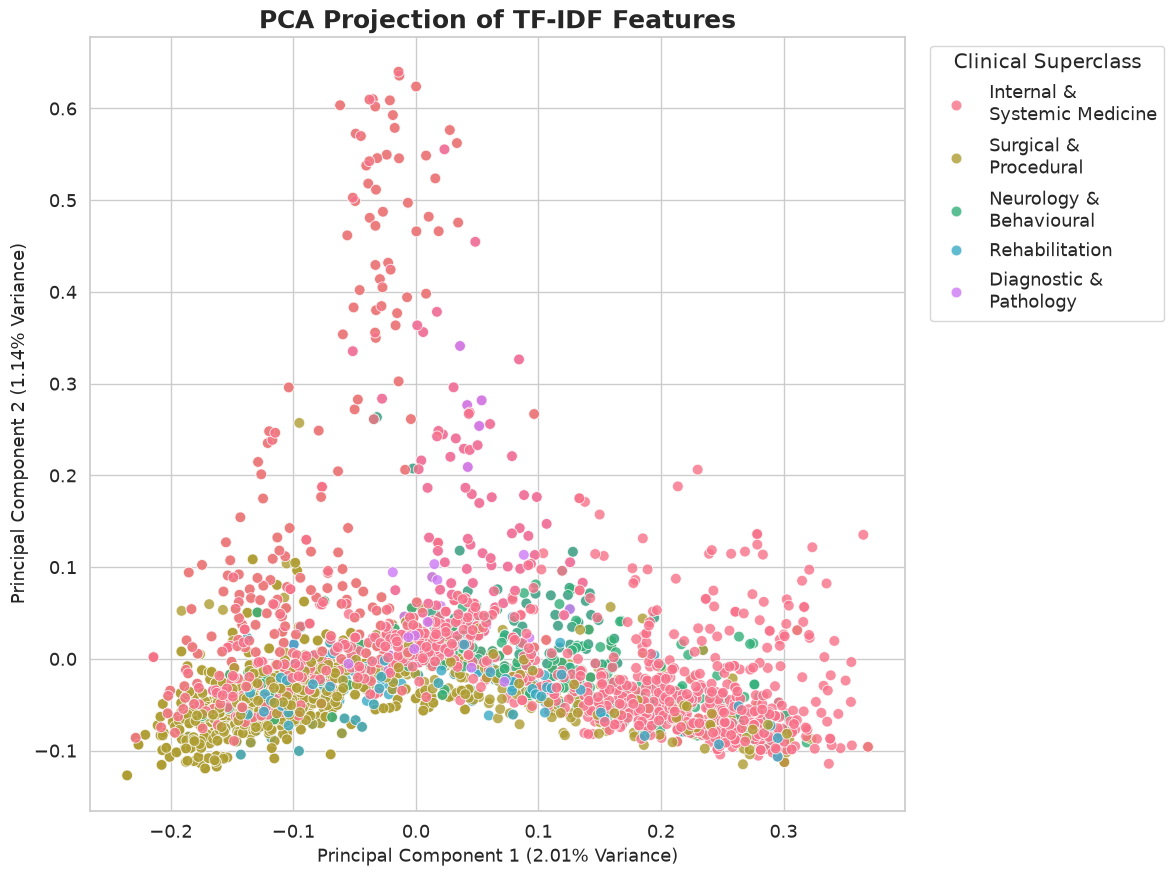

Variance explained by each component: [0.02010822 0.01138801]
Total variance captured: 3.15%


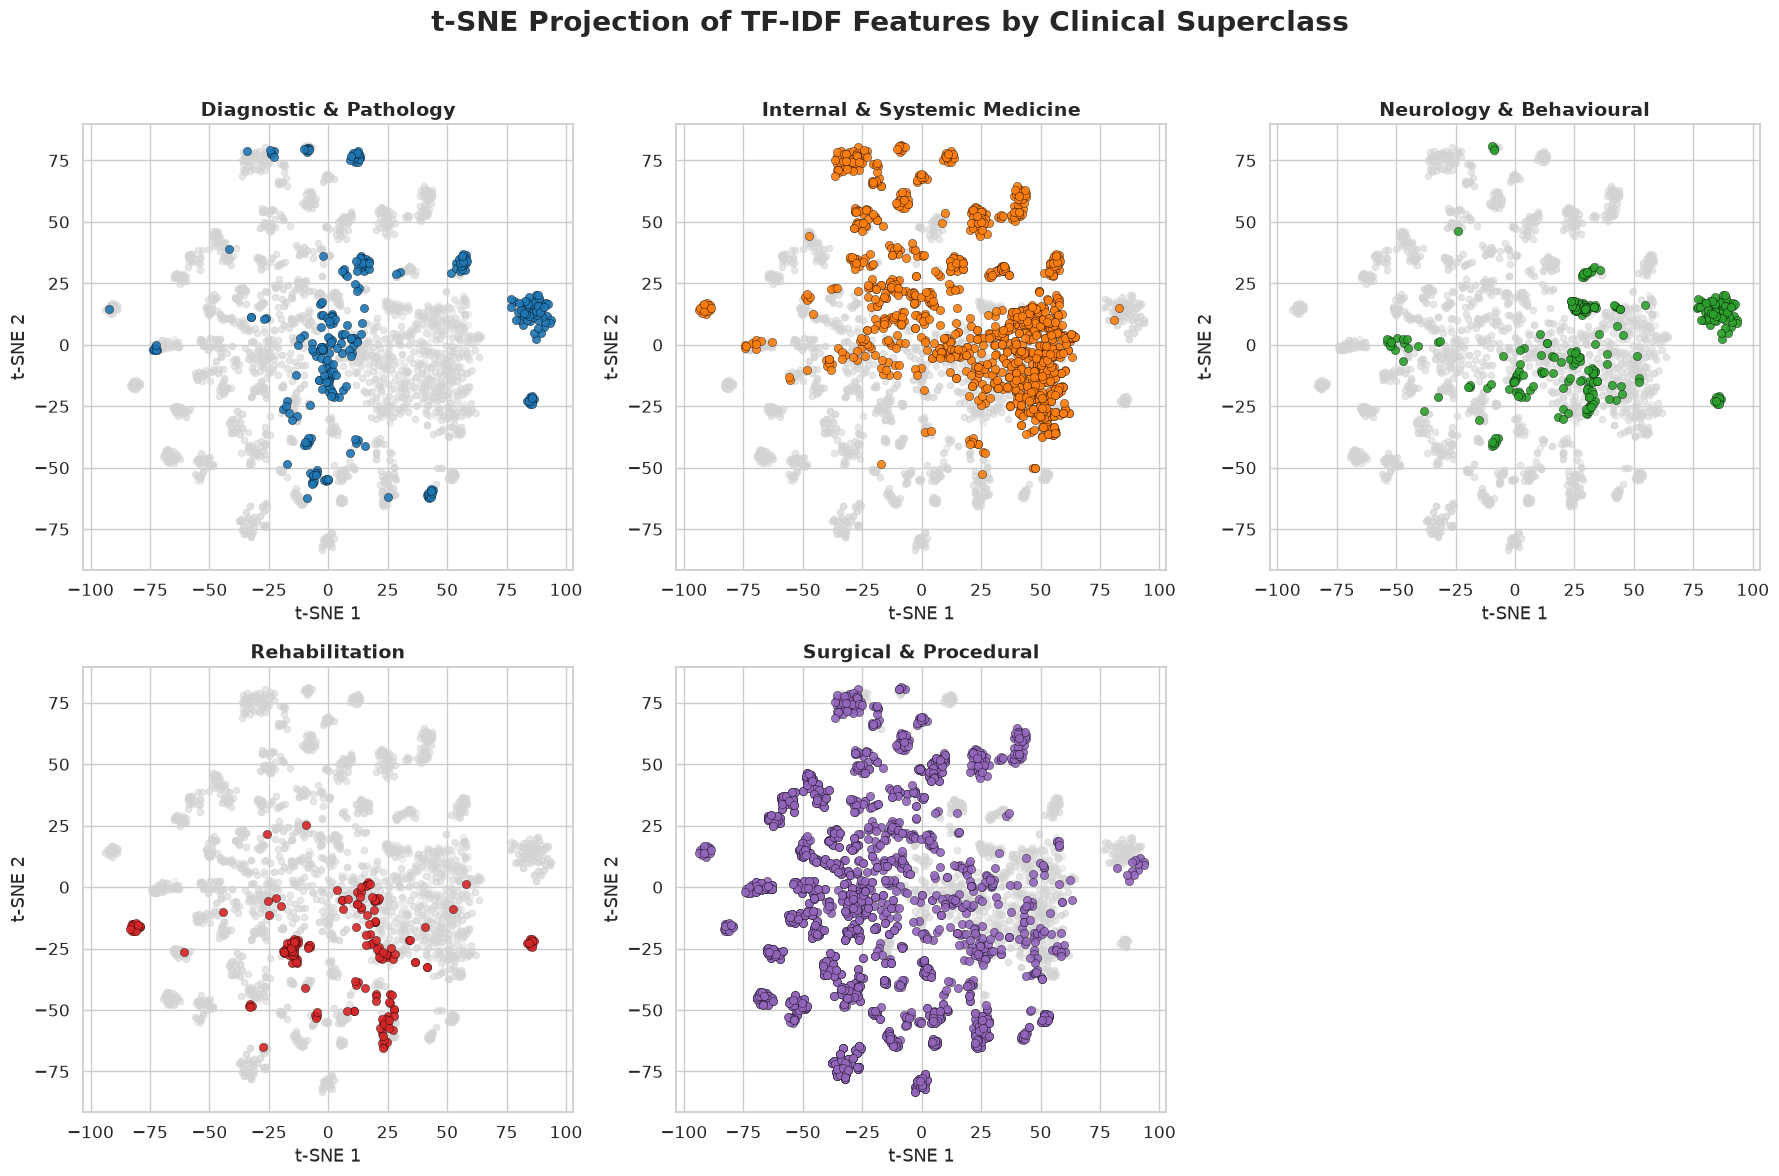

Variance explained by the 50 SVD components: 22.09%


In [16]:
##Apply PCA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# Create TF-IDF features for the entire dataset
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])
# Convert sparse matrix to dense
# Convert the TF-IDF matrix (NOT the vectorizer)
X_dense = X_tfidf.toarray()
# PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_dense)
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": df["clinical_superclass"]
})
# Mapping from original labels to human-readable labels
label_map = {
    "diagnostic_and_pathology": "Diagnostic &\nPathology",
    "internal_and_systemic_medicine": "Internal &\nSystemic Medicine",
    "neurology_and_behavioural": "Neurology &\nBehavioural",
    "rehab_and_applied_health": "Rehabilitation",
    "surgical_and_procedural": "Surgical &\nProcedural"
}

# Replace the class names
pca_df["Class"] = pca_df["Class"].replace(label_map)
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(12,9))
palette = sns.color_palette("husl", 5)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    palette=palette,
    s=60,
    alpha=0.8
)

plt.title(
    "PCA Projection of TF-IDF Features",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)",
    fontsize=13
)

plt.ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)",
    fontsize=13
)
# Human-readable class labels
class_labels = [
    "Diagnostic & Pathology",
    "Internal & Systemic Medicine",
    "Neurology & Behavioural",
    "Rehabilitation",
    "Surgical & Procedural"
]
plt.legend(
    title="Clinical Superclass",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../plots/PCA_TFIDF.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
# Examine explained variance
print(f"Variance explained by each component: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")


## With TSNE

from sklearn.decomposition import TruncatedSVD


# -------------------------------------------------------
# Create TF-IDF features
# -------------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])

# -------------------------------------------------------
# Reduce TF-IDF dimensions using TruncatedSVD
# (recommended for sparse text data)
# -------------------------------------------------------
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_reduced = svd.fit_transform(X_tfidf)

# -------------------------------------------------------
# Apply t-SNE
# -------------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_tsne = tsne.fit_transform(X_reduced)

# -------------------------------------------------------
# Create DataFrame
# -------------------------------------------------------
tsne_df = pd.DataFrame({
    "tSNE-1": X_tsne[:, 0],
    "tSNE-2": X_tsne[:, 1],
    "Class": df["clinical_superclass"]
})

# -------------------------------------------------------
# Human-readable labels
# -------------------------------------------------------
label_map = {
    "diagnostic_and_pathology": "Diagnostic &\nPathology",
    "internal_and_systemic_medicine": "Internal &\nSystemic Medicine",
    "neurology_and_behavioural": "Neurology &\nBehavioural",
    "rehab_and_applied_health": "Rehabilitation",
    "surgical_and_procedural": "Surgical &\nProcedural"
}

tsne_df["Class"] = tsne_df["Class"].replace(label_map)
# -------------------------------------------------------
# Plot one combined figure with 5 t-SNE subplots
# -------------------------------------------------------

sns.set_theme(style="whitegrid", font_scale=1.1)

palette = {
    "Diagnostic &\nPathology": "#1f77b4",
    "Internal &\nSystemic Medicine": "#ff7f0e",
    "Neurology &\nBehavioural": "#2ca02c",
    "Rehabilitation": "#d62728",
    "Surgical &\nProcedural": "#9467bd"
}

classes = list(palette.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(classes):

    ax = axes[i]

    # Plot all other classes in grey
    others = tsne_df[tsne_df["Class"] != cls]
    ax.scatter(
        others["tSNE-1"],
        others["tSNE-2"],
        color="lightgray",
        s=20,
        alpha=0.30
    )

    # Plot highlighted class
    current = tsne_df[tsne_df["Class"] == cls]
    ax.scatter(
        current["tSNE-1"],
        current["tSNE-2"],
        color=palette[cls],
        s=35,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_title(
        cls.replace("\n", " "),
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# Remove the unused sixth subplot
fig.delaxes(axes[5])

plt.suptitle(
    "t-SNE Projection of TF-IDF Features by Clinical Superclass",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "../plots/tSNE_by_superclass.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# Variance retained by TruncatedSVD
# -------------------------------------------------------
print(f"Variance explained by the 50 SVD components: {svd.explained_variance_ratio_.sum():.2%}")

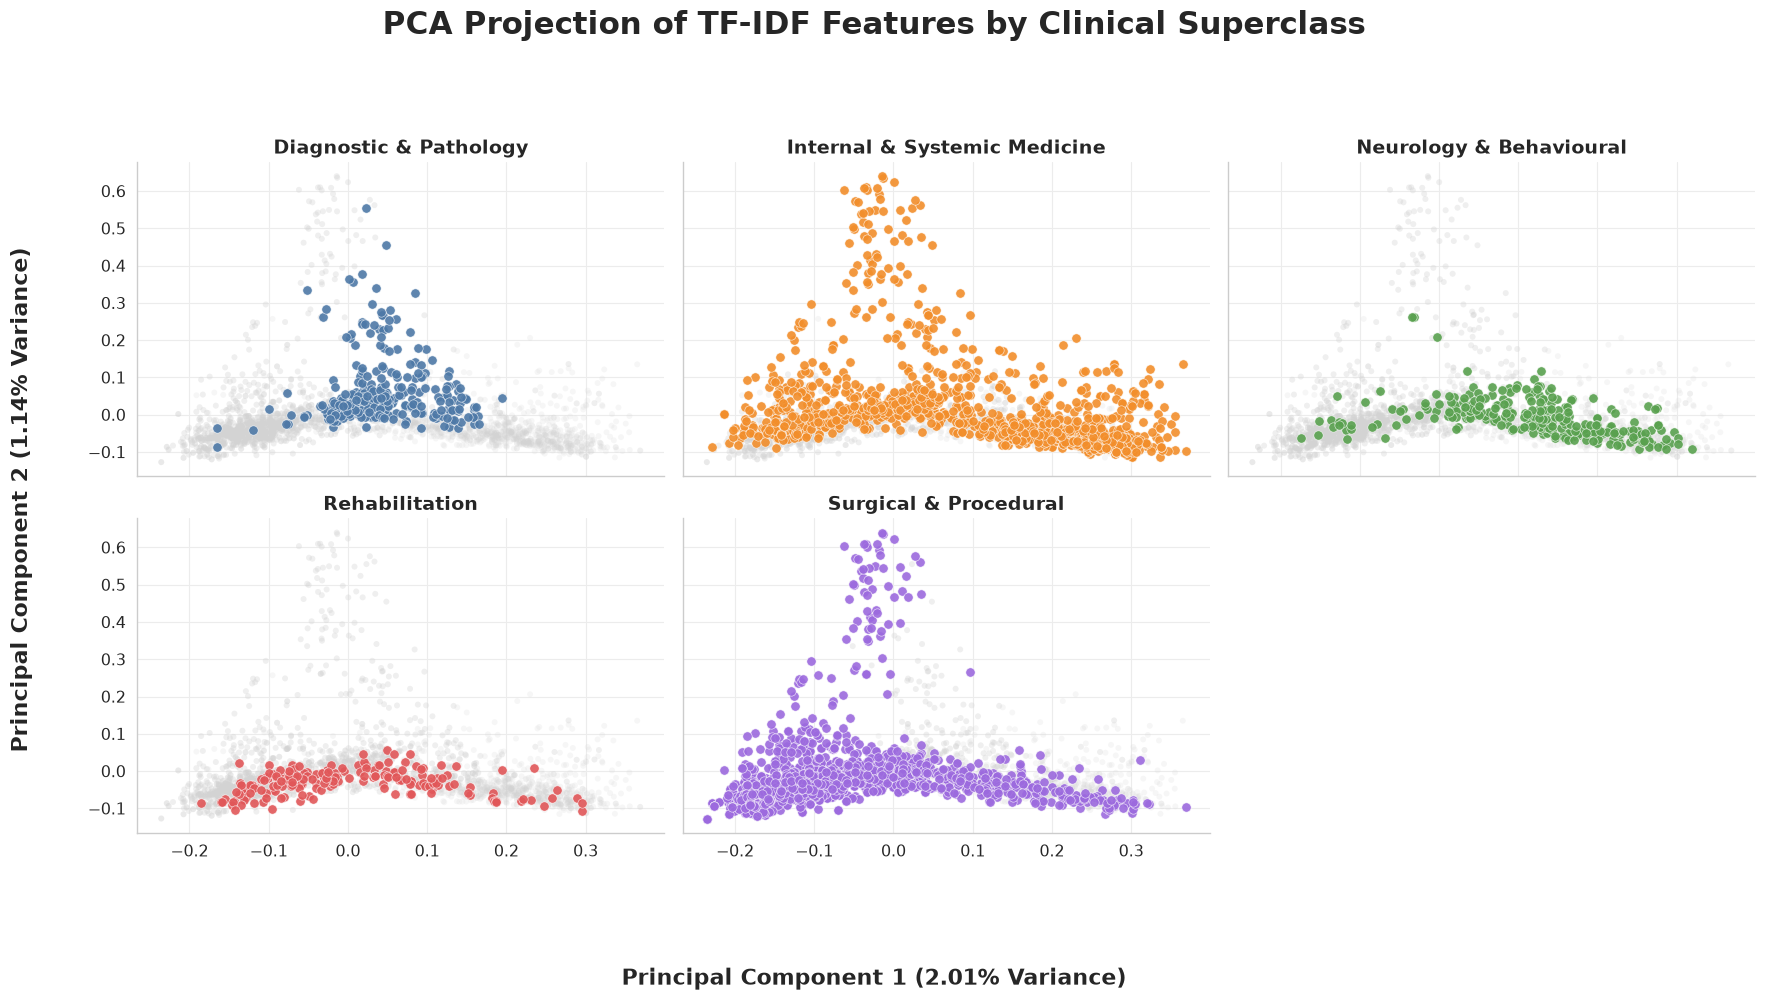

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Publication style
# -------------------------------------------------------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)

# -------------------------------------------------------
# Human-readable colours
# -------------------------------------------------------
palette = {
    "Diagnostic &\nPathology": "#4E79A7",
    "Internal &\nSystemic Medicine": "#F28E2B",
    "Neurology &\nBehavioural": "#59A14F",
    "Rehabilitation": "#E15759",
    "Surgical &\nProcedural": "#9C6ADE"
}

classes = list(palette.keys())

# -------------------------------------------------------
# Create figure
# -------------------------------------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# -------------------------------------------------------
# Draw one subplot per superclass
# -------------------------------------------------------
for ax, cls in zip(axes, classes):

    # Background classes
    background = pca_df[pca_df["Class"] != cls]

    ax.scatter(
        background["PC1"],
        background["PC2"],
        color="lightgrey",
        alpha=0.20,
        s=18,
        edgecolors="none"
    )

    # Highlighted class
    current = pca_df[pca_df["Class"] == cls]

    ax.scatter(
        current["PC1"],
        current["PC2"],
        color=palette[cls],
        edgecolor="white",
        linewidth=0.4,
        alpha=0.90,
        s=45
    )

    ax.set_title(
        cls.replace("\n"," "),
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(
        color="#ECECEC",
        linewidth=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -------------------------------------------------------
# Hide the empty panel
# -------------------------------------------------------
axes[-1].axis("off")

# -------------------------------------------------------
# Common labels
# -------------------------------------------------------
fig.supxlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)",
    fontsize=16,
    fontweight="bold"
)

fig.supylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)",
    fontsize=16,
    fontweight="bold"
)

# -------------------------------------------------------
# Main title
# -------------------------------------------------------
fig.suptitle(
    "PCA Projection of TF-IDF Features by Clinical Superclass",
    fontsize=22,
    fontweight="bold",
    y=0.99
)

# fig.text(
#     0.5,
#     0.955,
#     "Each panel highlights one superclass while all remaining documents are shown in grey.",
#     ha="center",
#     fontsize=12,
#     color="dimgray"
# )

# -------------------------------------------------------
# Shared legend
# -------------------------------------------------------
handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=palette[c],
        markeredgecolor="white",
        markersize=9,
        label=c.replace("\n"," ")
    )
    for c in classes
]

# fig.legend(
#     handles=handles,
#     loc="upper center",
#     ncol=5,
#     frameon=False,
#     fontsize=11,
#     title="Clinical Superclass",
#     title_fontsize=12
# )

plt.tight_layout(rect=[0.03,0.08,1,0.93])

plt.savefig(
    "../plots/PCA_Faceted_Clinical_Superclasses.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Multinormial Logistic Regression Model

In [10]:
#Learn the vocabulary from the training data | Computes IDF weights
X_train_tfidf = tfidf.fit_transform(X_train) #fit and transform X_train
X_test_tfidf = tfidf.transform(X_test) #just transform X_test

#Create the Logistic Regression model
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

#calculate Macro F1 average | cross validation
scores = cross_validate(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1_macro"
)

# print("Fold scores: ",scores)
# print(f"LR Mean Macro F1: {np.mean(scores["test_score"]):.2f}")

# Train the model
lr_model.fit(X_train_tfidf, y_train)

# Predict the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

#Time to Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.2f}")
print(classification_report(y_test, y_pred_lr))
print("-"*40)
# Define the features
X = df.cleaned_text
y = df.clinical_superclass

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
# Create a pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000,random_state=42))
])

param_grid = [
    {
    "tfidf__max_features": [5000,20000],
    "tfidf__min_df": [1,2, 3,5],
    "tfidf__max_df": [0.85,0.90,0.95],
    "tfidf__ngram_range": [(1,1), (1,2),(1,3)],
    "tfidf__norm":["l2"],
    "tfidf__sublinear_tf":[True,False],
    "lr__C": [0.01,0.1, 1, 5,10],
    "lr__l1_ratio": [0],
    "lr__solver": ['lbfgs', 'saga']
},
{
    "tfidf__max_features": [5000,20000],
        "tfidf__min_df": [1,2, 3,5],
        "tfidf__max_df": [0.85,0.90,0.95],
        "tfidf__ngram_range": [(1,1), (1,2),(1,3)],
        "tfidf__norm":["l2"],
        "tfidf__sublinear_tf":[True,False],
        "lr__C": [0.01,0.1, 1, 5,10],
        "lr__l1_ratio": [1],
        "lr__solver": ['saga']
}
]

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=0
)

# Train the pipeline
grid.fit(X_train, y_train)

# Best results
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(grid.best_score_)

#get the best model
best_model = grid.best_estimator_
y_pred_lr = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred_lr))



Accuracy: 0.64
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.35      0.56      0.43        87
internal_and_systemic_medicine       0.61      0.69      0.65       356
     neurology_and_behavioural       0.43      0.49      0.46        83
      rehab_and_applied_health       0.43      0.75      0.55        56
       surgical_and_procedural       0.84      0.64      0.73       622

                      accuracy                           0.64      1204
                     macro avg       0.53      0.63      0.56      1204
                  weighted avg       0.69      0.64      0.66      1204

----------------------------------------


KeyboardInterrupt: 

In [ ]:
# Build the model using the best parameters
logred_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        max_df=0.85,
        max_features=20000,
        min_df=5,
        ngram_range=(1, 1),
        norm='l2',
        sublinear_tf=False
    )),
    ('lr', LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        l1_ratio=0,
        solver='lbfgs',
        C=0.1
    ))
])

logred_pipeline.fit(X_train, y_train)
y_pred_lr = logred_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.70
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.41      0.59      0.49        86
internal_and_systemic_medicine       0.67      0.63      0.65       344
     neurology_and_behavioural       0.54      0.80      0.65        75
      rehab_and_applied_health       0.40      0.75      0.53        48
       surgical_and_procedural       0.85      0.73      0.78       651

                      accuracy                           0.70      1204
                     macro avg       0.58      0.70      0.62      1204
                  weighted avg       0.73      0.70      0.71      1204



                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.41      0.59      0.49        86
internal_and_systemic_medicine       0.67      0.63      0.65       344
     neurology_and_behavioural       0.54      0.80      0.65        75
      rehab_and_applied_health       0.40      0.75      0.53        48
       surgical_and_procedural       0.85      0.73      0.78       651

                      accuracy                           0.70      1204
                     macro avg       0.58      0.70      0.62      1204
                  weighted avg       0.73      0.70      0.71      1204



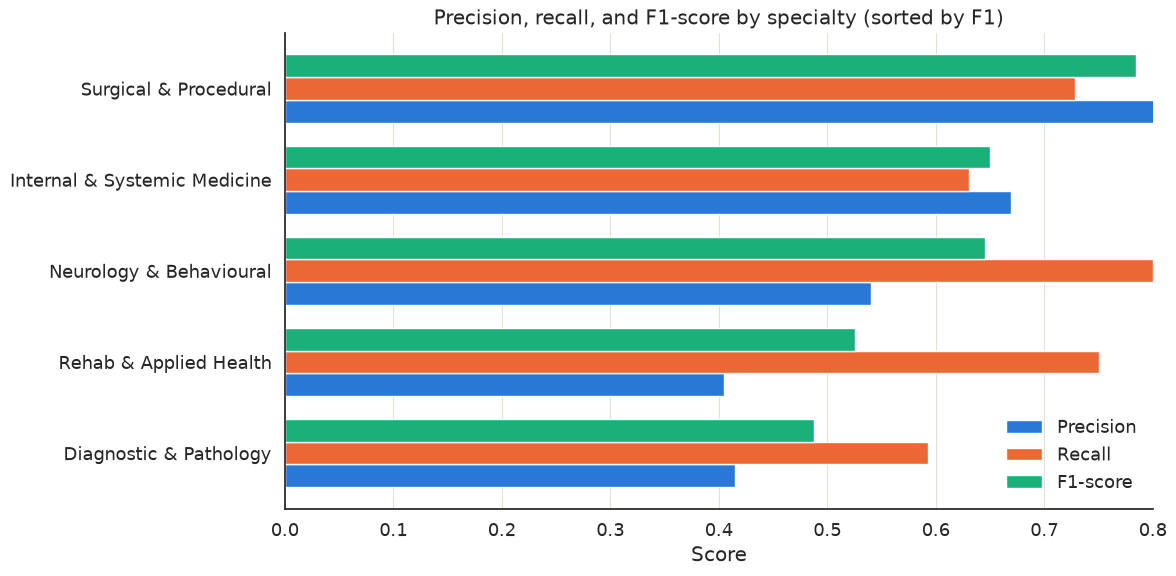

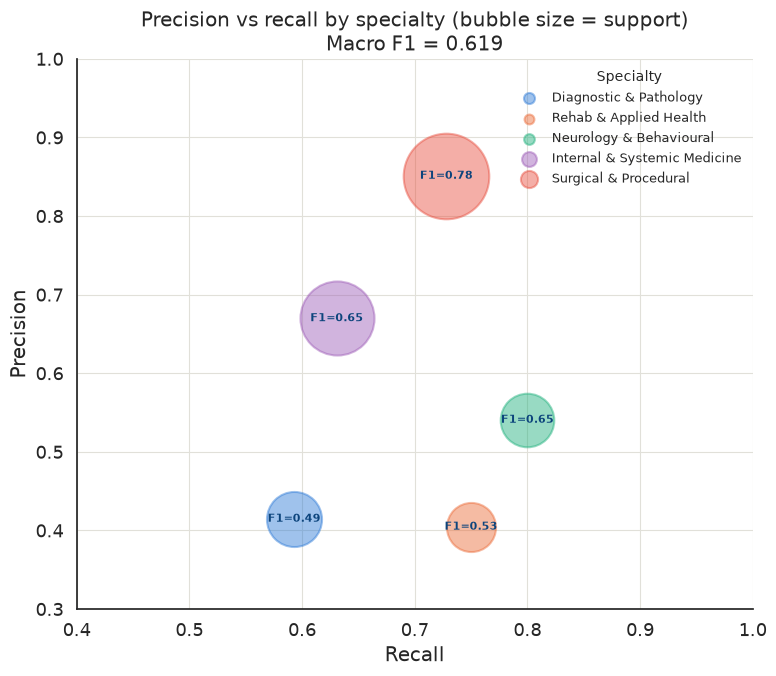

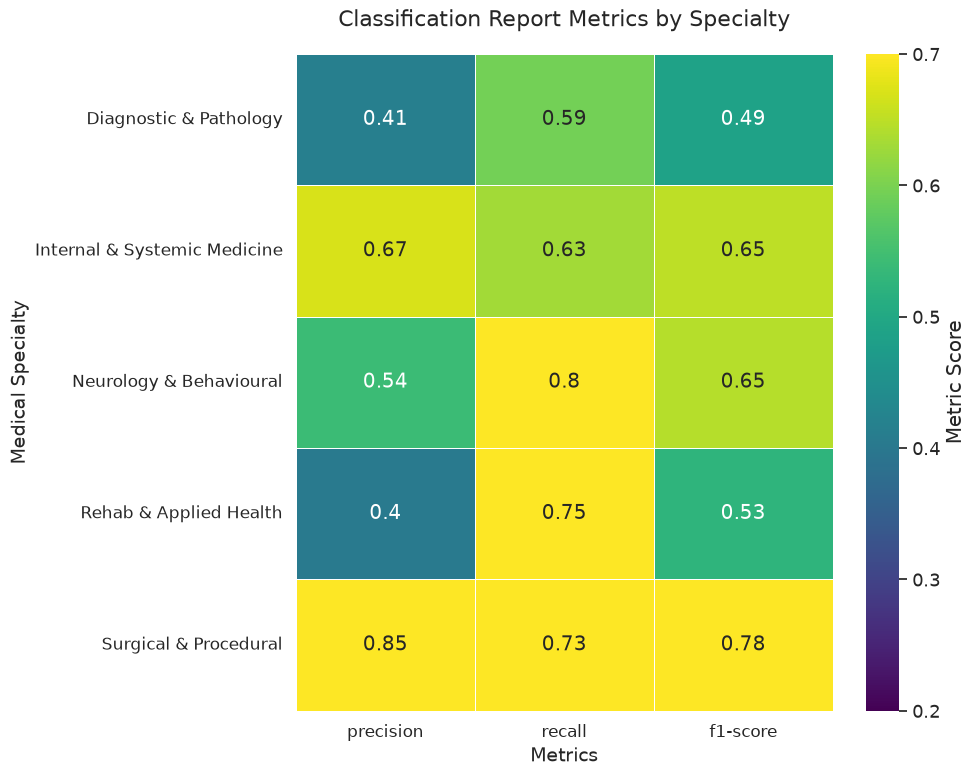

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(classification_report(y_test, y_pred_lr))

# --- Extract the report as a dataframe ---
report_dict = classification_report(y_test, y_pred_lr, output_dict=True)

# 'accuracy' is a lone scalar (not a nested dict like the other keys), so pull
# it out first -- leaving it in breaks a clean DataFrame transpose.
overall_accuracy = report_dict.pop('accuracy')
macro_f1 = report_dict['macro avg']['f1-score']

report_df = pd.DataFrame(report_dict).transpose()
report_df.index.name = 'specialty'
report_df = report_df.reset_index()

# Keep only per-class rows for the plots (drop the avg rows)
report_df = report_df[~report_df['specialty'].isin(['macro avg', 'weighted avg'])]

# ============================================================
# NEW: Map raw class names to professional display names
# ============================================================
name_map = {
    'surgical_and_procedural': 'Surgical & Procedural',
    'internal_and_systemic_medicine': 'Internal & Systemic Medicine',
    'neurology_and_behavioural': 'Neurology & Behavioural',
    'rehab_and_applied_health': 'Rehab & Applied Health',
    'diagnostic_and_pathology': 'Diagnostic & Pathology',
}
report_df['specialty'] = report_df['specialty'].map(name_map)

# Sort by F1 ascending -- worst-performing classes first, easiest to scan
report_df = report_df.sort_values('f1-score', ascending=True).reset_index(drop=True)

# ============================================================
# Chart 1: Grouped horizontal bar chart -- precision / recall / F1 per class
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(report_df))
bar_height = 0.25

ax.barh(y_pos - bar_height, report_df['precision'], height=bar_height, label='Precision', color='#2a78d6')
ax.barh(y_pos,              report_df['recall'],    height=bar_height, label='Recall',    color='#eb6834')
ax.barh(y_pos + bar_height, report_df['f1-score'],  height=bar_height, label='F1-score',  color='#1baf7a')

ax.set_yticks(y_pos)
ax.set_yticklabels(report_df['specialty'])
ax.set_xlabel('Score')
ax.set_xlim(0, 0.8)
ax.set_title('Precision, recall, and F1-score by specialty (sorted by F1)')
ax.legend(loc='lower right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../plots/classification_report_by_f1.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# Chart 2: Precision vs recall bubble chart
# bubble size = support, annotated with per-class F1 (inside bubble)
# and overall macro F1 (in the chart title)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

max_support = report_df['support'].max()
# Area-proportional bubble sizing (sqrt scaling) -- tune the multiplier (3500)
# if bubbles look too small/large for your figure size
sizes = 300 + 3500 * np.sqrt(report_df['support'] / max_support)

# NEW: Assign a distinct color to each class
palette = ['#2a78d6', '#eb6834', '#1baf7a', '#9b59b6', '#e74c3c']
colors = [palette[i % len(palette)] for i in range(len(report_df))]

for i, (_, row) in enumerate(report_df.iterrows()):
    ax.scatter(
        row['recall'],
        row['precision'],
        s=sizes.iloc[i] if hasattr(sizes, 'iloc') else sizes[i],
        color=colors[i],
        alpha=0.45,
        edgecolor=colors[i],
        linewidth=1.5,
        label=row['specialty'],   # label for legend
    )

    # NEW: Only annotate F1 inside the bubble; names removed from above
    ax.annotate(
        f"F1={row['f1-score']:.2f}",
        (row['recall'], row['precision']),
        ha='center',
        va='center',
        fontsize=8,
        color='#0c447c',
        fontweight='bold',
    )

# NEW: Add legend so colors are identifiable
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend entries (scatter adds one per point)
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    title='Specialty',
    loc='upper right',
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    scatterpoints=1,
    markerscale=0.2
)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.3, 1.0)
ax.set_title(f'Precision vs recall by specialty (bubble size = support)\nMacro F1 = {macro_f1:.3f}')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../plots/precision_recall_tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# 1. Generate the report as a dictionary instead of a string
# Assuming y_test_ft and y_pred_lr are already defined in your environment
report_dict = classification_report(y_test, y_pred_lr, output_dict=True)

# 2. Convert to a Pandas DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# 3. Drop the 'support' column for the color mapping (so it doesn't skew the 0-1 scale)
# We will drop accuracy as well to keep the grid focused on class-level metrics
metrics_df = report_df.drop(columns=['support']).drop(['accuracy', 'macro avg', 'weighted avg'])

# NEW: Apply the same professional name mapping to the heatmap index
metrics_df.index = metrics_df.index.map(
    lambda x: name_map.get(x, x) if 'name_map' in globals() else x
)

# 4. Initialize the matplotlib figure
plt.figure(figsize=(10, 8))

# 5. Create the heatmap
ax = sns.heatmap(
    metrics_df, 
    annot=True,          # Show the numbers inside the squares
    cmap='viridis',      # Matches your previous super-class plot theme
    vmin=0.2, vmax=0.7,  # Anchor the color scale to your specific data range
    linewidths=0.5, 
    cbar_kws={'label': 'Metric Score'}
)

# 6. Formatting
plt.title('Classification Report Metrics by Specialty', fontsize=16, pad=20)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Medical Specialty', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig('../plots/metrics_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


#### Confusion Matrixt

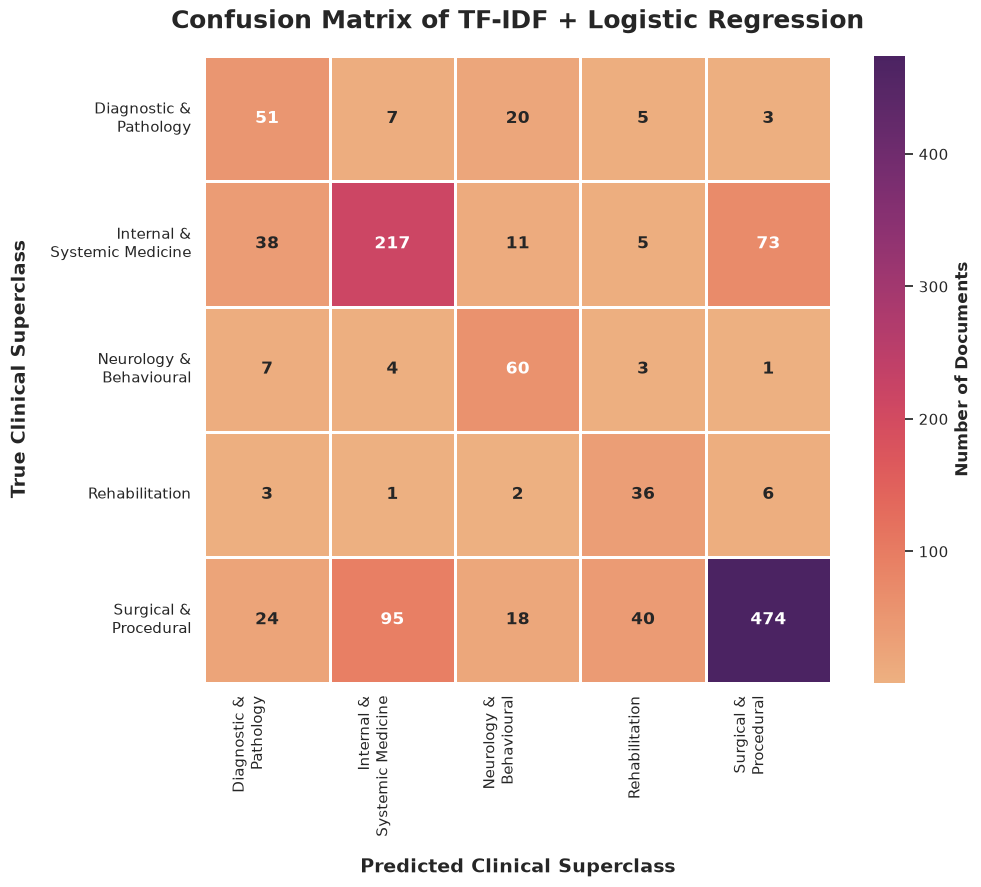

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Human-readable class labels
class_labels = [
    "Diagnostic &\nPathology",
    "Internal &\nSystemic Medicine",
    "Neurology &\nBehavioural",
    "Rehabilitation",
    "Surgical &\nProcedural"
]

# Publication style
sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(11, 9))

# Plot confusion matrix
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="flare",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

# Title
ax.set_title(
    "Confusion Matrix of TF-IDF + Logistic Regression",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Predicted Clinical Superclass",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

ax.set_ylabel(
    "True Clinical Superclass",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

# Tick labels
plt.xticks(rotation=90, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Colour bar
cbar = ax.collections[0].colorbar
cbar.set_label(
    "Number of Documents",
    fontsize=12,
    fontweight="bold"
)
cbar.ax.tick_params(labelsize=11)

# Remove unnecessary borders
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save figure
plt.savefig(
    "../plots/TFIDF_LogisticRegression_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Xgboost Classifier with TF-IDF

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df.clinical_superclass)

#Split into X and y
X = df.transcription
y = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("xgb", XGBClassifier(
        objective="multi:softmax",
        num_class=9,
        random_state=42,
        eval_metric="mlogloss",
        tree_method = "hist"
    ))
])
scores = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print(scores["test_score"])
print(np.mean(scores["test_score"]))
param_grid = {

    "tfidf__max_features":[5000,10000],
    "tfidf__min_df":[2,5],
    "tfidf__ngram_range":[(1,1),(1,2)],
    "xgb__n_estimators":[200,300,400],
    "xgb__max_depth":[3,5],
    "xgb__learning_rate":[0.01,0.1,0.2],

    "xgb__subsample":[0.8,1],

    #"xgb__colsample_bytree":[0.8,1]
}
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
print("Best Parameters")
print(grid.best_params_)

print()

print("Best Macro F1")
print(grid.best_score_)

print()

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

[0.39817618 0.39879954 0.39313644 0.34813535 0.43220257]
0.39409001492129886


KeyboardInterrupt: 

In [ ]:
print("=" * 100)
print("LINEAR SVC - BEFORE HYPERPARAMETER TUNING".center(100))
print("=" * 100)

print("\nCross-Validation Results")
print("-" * 100)
print("Fold Scores:", scores["test_score"])
print(f"Mean Macro F1 : {np.mean(scores['test_score']):.4f}")

print("\nTest Set Performance")
print("-" * 100)
print(f"Accuracy      : {accuracy_score(y_test, y_pred_svc):.4f}")
print("\nClassification Report")
print(classification_report(y_test, y_pred_svc))


print("\n" + "=" * 100)
print("LINEAR SVC - AFTER HYPERPARAMETER TUNING".center(100))
print("=" * 100)

print("\nBest Hyperparameters")
print("-" * 100)
for param, value in grid.best_params_.items():
    print(f"{param:<25}: {value}")

print(f"\nBest CV Macro F1 : {grid.best_score_:.4f}")


print("\nTest Set Performance")
print("-" * 100)
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))


print("\n\n" + "=" * 100)
print("LOGISTIC REGRESSION - BEFORE HYPERPARAMETER TUNING".center(100))
print("=" * 100)

print("\nCross-Validation Results")
print("-" * 100)
print("Fold Scores:", scores["test_score"])
print(f"Mean Macro F1 : {np.mean(scores['test_score']):.4f}")

print("\nTest Set Performance")
print("-" * 100)
print(f"Accuracy      : {accuracy_lr:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))


print("\n" + "=" * 100)
print("LOGISTIC REGRESSION - AFTER HYPERPARAMETER TUNING".center(100))
print("=" * 100)

print("\nBest Hyperparameters")
print("-" * 100)
for param, value in grid.best_params_.items():
    print(f"{param:<25}: {value}")

print(f"\nBest CV Macro F1 : {grid.best_score_:.4f}")


print("\nTest Set Performance")
print("-" * 100)
print(f"Accuracy      : {accuracy_score(y_test, y_pred_lr):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\n" + "=" * 100)
print("END OF MODEL COMPARISON".center(100))
print("=" * 100)

                             LINEAR SVC - BEFORE HYPERPARAMETER TUNING                              

Cross-Validation Results
----------------------------------------------------------------------------------------------------
Fold Scores: [0.58005277 0.5344776  0.5242648  0.55548728 0.59258556]
Mean Macro F1 : 0.5574

Test Set Performance
----------------------------------------------------------------------------------------------------
Accuracy      : 0.5756

Classification Report
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.16      0.21      0.18        86
internal_and_systemic_medicine       0.51      0.56      0.53       344
     neurology_and_behavioural       0.35      0.44      0.39        75
      rehab_and_applied_health       0.37      0.42      0.39        48
       surgical_and_procedural       0.75      0.66      0.70       651

                      accuracy                           0.58      1204
    